In [85]:
%pip install -U langgraph
%pip install -U langchain

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [86]:

import os

from typing import Annotated, List, Literal, Optional
from pydantic import BaseModel, Field

from langchain_core.messages import AnyMessage
from langchain_core.messages import HumanMessage, AIMessage
from langchain.chat_models import init_chat_model

from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END

import requests


In [87]:

class RunnerProfile(BaseModel):
    name: str
    age: int
    sex: Literal["male", "female", "other"]
    experience_level: Literal["beginner", "intermediate", "advanced"]
    weekly_mileage_km: float = Field(..., description="Current average weekly mileage in km")
    preferred_units: Literal["km", "mi"] = "km"
    available_days: List[Literal["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]]
    constraints: List[str] = Field(
        default_factory=list,
        description="Injuries, schedule constraints, etc"
    )

class RecentRun(BaseModel):
    date: str
    distance_km: float
    duration_min: float
    avg_pace_min_per_km: float
    notes: Optional[str] = None

In [88]:
class Workout(BaseModel):
    day: Literal["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    focus: Literal["easy", "long_run", "intervals", "tempo", "recovery", "rest"]
    distance_km: float = Field(..., description="Planned distance in km (0 if rest)")
    target_pace_min_per_km: Optional[float] = Field(
        None, description="Leave None for recovery or rest workouts."
    )
    description: str = Field(..., description="Plain-language description of the workout")
    notes: Optional[str] = None

class WeeklyPlan(BaseModel):
    week_number: int = Field(..., description="Week number in the overall plan")
    focus_summary: str = Field(..., description="High-level weekly focus or theme")
    workouts: List[Workout] = Field(..., description="List of daily workouts for this week")

class TrainingPlan(BaseModel):
    goal_description: str = Field(..., description="High-level description of the overall goal")
    plan_duration_weeks: int = Field(..., description="Total number of weeks in the plan")
    weekly_overview: str = Field(..., description="Summary of how training load evolves week by week")
    weekly_plans: List[WeeklyPlan] = Field(..., description="List of structured weekly plans")

In [89]:

class TestOverallState(BaseModel):
    instruction: str
    country: str
    
    # user inputs
    runner_profile: Optional[RunnerProfile] = None
    weeks: int | None = None
    recent_runs: Optional[List[RecentRun]] = None
    goal_description: str | None = None

    # system state
    approved: bool | None = None
    intent: str | None = None
    
    # weather state
    country: str
    avg_temp: Optional[float] = None
    avg_humidity: Optional[float] = None
    
    plan: TrainingPlan | None = None
    
    # messages: Annotated[List[AnyMessage], add_messages] = []
    # LangGraph message history
    messages: Annotated[List[AnyMessage], add_messages] = Field(
        default_factory=list
    )
    model_config = {"arbitrary_types_allowed": True}

In [120]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")


In [121]:
model = init_chat_model(
    "gpt-4.1",
    temperature=0
    )

# 1. Nodes and Tools

## 1.1 Planner node

In [91]:
from langchain_core.prompts import ChatPromptTemplate

In [92]:
def planner_node(state: TestOverallState):
    """
    Generate a running training plan using the user's inputs.
    """
    print("Running Planning")

    # --- Inputs from state ---
    weeks = state.weeks or 8
    runner_profile = state.runner_profile or "Runner profile unavailable."
    recent_runs = state.recent_runs or "No recent runs provided."
    goal_description = state.goal_description or "No goal specified."

    # If runner_profile is a Pydantic model, convert to dict or nicely formatted string
    if not isinstance(runner_profile, str):
        runner_profile_text = runner_profile.model_dump()
    else:
        runner_profile_text = runner_profile

    # --- System guidance ---
    system_msg = """
        You are a long-distance running coach.

        You must:
        - Be conservative about sudden mileage increases.
        - Respect injuries and constraints.
        - Use the runner's preferred units (km or miles).
        - Align workouts with available days.
        - Include pace or effort where possible.
        - Reply STRICTLY using the TrainingPlan JSON schema (no extra keys).
    """

    # --- Prompt template ---
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_msg),
            (
                "human",
                """Create a {weeks}-week training plan.

                Runner profile:
                {runner_profile}

                Recent runs (last 2–4 weeks):
                {recent_runs}

                Goal:
                {goal_description}
                """,
            ),
        ]
    )

    # --- Chain: prompt → model (structured as TrainingPlan) ---
    plan_chain = prompt | model.with_structured_output(TrainingPlan)

    # --- Invoke the chain with variables ---
    plan: TrainingPlan = plan_chain.invoke(
        {
            "weeks": weeks,
            "runner_profile": runner_profile_text,
            "recent_runs": recent_runs,
            "goal_description": goal_description,
        }
    )

    # Turn structured plan into a readable JSON string for `plan` / logs
    plan_text = plan.model_dump_json(indent=2)

    # --- Update state messages ---
    messages = state.messages or []
    messages.append(
        HumanMessage(
            content=f"Generate a {weeks}-week training plan for:\n{goal_description}"
        )
    )
    messages.append(AIMessage(content=plan_text))

    return {
        "plan": plan,      # nice stringified plan
        "messages": messages,
    }


## 1.2 Intent Classifier

In [93]:
def classify_intent_node(state: TestOverallState):
    print("Running Intent Classification")
    
    prompt = f"""You are an intent classifier.
    User instruction: "{state.instruction}"

    Possible intents: ["planning", "revise", "advice"]
    For now always return "planning".
    Respond with only the intent label.
    """
    response = model.invoke(prompt)
    intent = response.content.strip().lower()
    messages = state.messages or []
    messages.append(
        HumanMessage(content=f"[INTENT CLASSIFICATION INPUT]\n{state.instruction}")
    )
    messages.append(AIMessage(content=f"[INTENT CLASSIFICATION OUTPUT]\n{intent}"))

    return {
        "intent": intent,
        "messages": messages,
    }


def route_from_intent(state: TestOverallState):
    if state.intent == "planning":
        return "weather_node"
    else:
        return END

## 1.3 Safety Check Cycle

In [94]:
def safety_node(state: TestOverallState):
    prompt = f"""
You are RunBuddy's safety evaluator.

Your job is to check whether the following generated training plan looks
reasonable and safe for the runner.

User instruction:
{state.instruction}

Training plan to review:
{state.plan.model_dump()}

Consider the following:
- Are there any unsafe or excessive weekly mileage increases?
- Are there enough rest or easy days?
- Does the plan escalate volume and intensity gradually?
- Does it appear achievable for a normal recreational runner?
- Are injury or overtraining risks mentioned or implicitly handled?

Respond with a short, **verbose evaluation** beginning with either:
"approved" – if the plan looks safe enough overall,
or
"reject" – if the plan seems unsafe or poorly structured.

Then briefly justify your reasoning.
"""
    print("Running Safety Check")
    response = model.invoke(prompt)
    full_verdict_text = response.content.strip()
    lower_verdict = full_verdict_text.lower()

    approved = lower_verdict.startswith("approved")

    # Append this evaluation to the shared message history
    messages = state.messages or []
    messages.append(AIMessage(content=f"[SAFETY CHECK]\n{full_verdict_text}"))
    
    next_plan = state.plan if approved else None
    
    return {
        "approved": approved,
        "plan": next_plan,
        "messages": messages,
    }


def route_from_checker(state: TestOverallState):
    # example: if approved, finish; else, re-run the pipeline
    if state.approved:
        return END
    else:
        return "classify_intent_node"


## 1.4 Weather checker

In [95]:
COUNTRY_COORDS = [
    {"country": "United States", "lat": 25.257210602287614, "lon": -80.97441392346366},
    {"country": "Germany", "lat": 54.060926054194226, "lon": 8.675224235010603},
    {"country": "United Kingdom", "lat": 49.96116246897293, "lon": -6.287672695838069},
    {"country": "Australia", "lat": -14.581268346157117, "lon": 125.11939537829426},
    {"country": "Spain", "lat": 42.460129323909314, "lon": 1.9690796575003446},
    {"country": "Canada", "lat": 59.09959989681795, "lon": -80.55761278260366},
    {"country": "Colombia", "lat": 13.577467241420209, "lon": -80.09011278407758},
    {"country": "Japan", "lat": 36.65362538180608, "lon": 139.26813805372842},
    {"country": "Malaysia", "lat": 5.905167059312475, "lon": 102.75789359131636},
    {"country": "Belarus", "lat": 53.531880481998826, "lon": 28.03356645962458},
    {"country": "Switzerland", "lat": 46.97259012423501, "lon": 8.210718017522652},
    {"country": "Italy", "lat": 43.43708737088565, "lon": 9.905662298976097},
    {"country": "Norway", "lat": 64.17441442668462, "lon": 9.384151079608785},
    {"country": "Netherlands", "lat": 53.54190901728748, "lon": 6.586033588379564},
    {"country": "France", "lat": 48.872711262714745, "lon": -1.8321230027742104},
    {"country": "Mexico", "lat": 22.578678342231854, "lon": -89.77301445015661},
    {"country": "Brazil", "lat": -13.457554413105527, "lon": -38.96377043295894},
    {"country": "Taiwan", "lat": 23.271396389032304, "lon": 119.50119537396756},
    {"country": "Peru", "lat": -13.58782829723799, "lon": -71.85199286188094},
    {"country": "Russia", "lat": 42.91223065102389, "lon": 131.7274769428068},
    {"country": "Luxembourg", "lat": 49.76679437835804, "lon": 6.071789535958487},
    {"country": "Sweden", "lat": 58.425004813421594, "lon": 16.963267914382925},
    {"country": "Singapore", "lat": 1.3589241607215854, "lon": 103.81346452416864},
    {"country": "Slovenia", "lat": 46.063557686138495, "lon": 14.940281412357479},
    {"country": "Costa Rica", "lat": 10.103360464913692, "lon": -85.17369544219076},
    {"country": "Indonesia", "lat": 0.5441717886972697, "lon": 104.22862871724169},
    {"country": "Denmark", "lat": 55.7628504713723, "lon": 10.304027743485733},
    {"country": "Austria", "lat": 47.58565692342842, "lon": 14.130672916921753},
    {"country": "Poland", "lat": 52.12477121721804, "lon": 19.394323120415834},
    {"country": "Chile", "lat": -38.31463301540117, "lon": -73.96774137166682},
    {"country": "South Africa", "lat": -29.009215741912783, "lon": 25.15924152977294},
    {"country": "Belgium", "lat": 50.83668469454318, "lon": 4.370396733222833},
    {"country": "China", "lat": 24.558051104674917, "lon": 118.31909670904611},
    {"country": "Isle of Man", "lat": 54.05096389246984, "lon": -4.815939839551788},
    {"country": "Cayman Islands", "lat": 19.681312926350643, "lon": -80.077397224702},
    {"country": "Iceland", "lat": 65.12923714897539, "lon": -22.560159204783304},
    {"country": "Portugal", "lat": 40.13375491445788, "lon": -8.82449861202116},
    {"country": "Romania", "lat": 45.85346826984494, "lon": 24.972949302568395},
    {"country": "Thailand", "lat": 12.697066933892074, "lon": 100.78755670687667},
    {"country": "Estonia", "lat": 58.14953739583433, "lon": 22.504479923409917},
    {"country": "Finland", "lat": 65.637151417604, "lon": 24.85609624774378},
    {"country": "Moldova", "lat": 47.1951013921157, "lon": 28.461397116284047},
    {"country": "South Korea", "lat": 36.43732885374379, "lon": 127.88014001934664},
    {"country": "Argentina", "lat": -54.753670235992445, "lon": -64.28538977771592},
    {"country": "Czechia", "lat": 49.73244820552043, "lon": 15.31410310187681},
    {"country": "Ukraine", "lat": 45.69260332668233, "lon": 29.934702995646887},
    {"country": "Slovakia", "lat": 48.70493508808403, "lon": 19.480382926131313},
    {
        "country": "Dominican Republic",
        "lat": 18.150732872624133,
        "lon": -68.68345802786553,
    },
    {"country": "Israel", "lat": 31.028641443248148, "lon": 34.657992593483584},
    {"country": "Guatemala", "lat": 15.007764594360708, "lon": -91.24008643324214},
    {"country": "Jersey", "lat": 49.23009823214784, "lon": -2.1251419752218226},
    {"country": "Ireland", "lat": 53.30484793998062, "lon": -9.859185960463549},
    {"country": "Turkey", "lat": 38.43719944539828, "lon": 26.343136992478378},
    {
        "country": "United Arab Emirates",
        "lat": 25.091870009393574,
        "lon": 55.14685377718024,
    },
    {"country": "Uruguay", "lat": -32.800158283377925, "lon": -56.017869705722205},
    {"country": "New Zealand", "lat": -40.85717862159595, "lon": 174.91205007495114},
    {"country": "Hungary", "lat": 47.16324368654705, "lon": 19.39675926692678},
    {"country": "Philippines", "lat": 6.436207877291849, "lon": 120.78525193922576},
    {"country": "Myanmar", "lat": 15.72937490962454, "lon": 95.0446362867354},
    {"country": "Greece", "lat": 36.15541785035367, "lon": 29.49679477535875},
    {"country": "India", "lat": 9.197786835594172, "lon": 79.07240647877614},
    {"country": "Croatia", "lat": 44.5101131571966, "lon": 14.297722781081632},
    {"country": "Panama", "lat": 8.107804517364741, "lon": -82.33765428851444},
    {"country": "Cyprus", "lat": 34.98052744588506, "lon": 33.785565225554876},
    {"country": "Vietnam", "lat": 9.805500662225938, "lon": 104.63844781581423},
    {"country": "Guernsey", "lat": 49.4633583014446, "lon": -2.5773483701310056},
    {"country": "Mongolia", "lat": 46.75022357525796, "lon": 95.77853835046466},
    {"country": "Lithuania", "lat": 55.36037655233616, "lon": 21.029185417273368},
    {"country": "Bolivia", "lat": -16.706876766549385, "lon": -64.68475359110516},
    {"country": "Andorra", "lat": 42.541326524999306, "lon": 1.5607562412077414},
    {"country": "El Salvador", "lat": 13.73677620096106, "lon": -88.86950657436876},
    {"country": "Latvia", "lat": 56.633417305664295, "lon": 26.40511559780674},
    {"country": "Nicaragua", "lat": 14.806710735911906, "lon": -82.69355198153858},
    {"country": "Jordan", "lat": 30.63632414004718, "lon": 37.12067528943322},
    {"country": "Ecuador", "lat": 1.2970016748875537, "lon": -78.93783436746196},
    {"country": "Kazakhstan", "lat": 46.40595944747071, "lon": 52.988075281349325},
    {"country": "Kosovo", "lat": 42.57288318431165, "lon": 20.87374334198182},
    {"country": "Bulgaria", "lat": 42.76853191221812, "lon": 25.21749754347701},
    {"country": "Malta", "lat": 35.89060389975032, "lon": 14.441357832598044},
    {"country": "Kenya", "lat": -2.1021243904281164, "lon": 41.05869519942411},
    {"country": "Venezuela", "lat": 11.414669636694555, "lon": -63.04585337333435},
    {"country": "Serbia", "lat": 43.90765927275737, "lon": 21.04587772567669},
    {"country": "Zimbabwe", "lat": -19.002536710200843, "lon": 29.851884620878707},
    {"country": "Monaco", "lat": 43.74614075179443, "lon": 7.398448957853304},
    {"country": "Montenegro", "lat": 42.78581616068743, "lon": 19.23849855986083},
    {"country": "Suriname", "lat": 4.128548348827394, "lon": -55.91223348738538},
    {"country": "Armenia", "lat": 40.28859678761182, "lon": 44.9317308780777},
    {"country": "Bahrain", "lat": 26.04913238465201, "lon": 50.54390058364521},
    {"country": "Honduras", "lat": 15.958972022241198, "lon": -86.49306857755266},
    {"country": "Tunisia", "lat": 37.526080444357206, "lon": 8.929563835702595},
    {"country": "Nigeria", "lat": 4.44437705655605, "lon": 7.235954648188624},
    {"country": "Barbados", "lat": 13.147694562654124, "lon": -59.54057776565122},
    {"country": "Ghana", "lat": 7.953953003728316, "lon": -1.2165289800282721},
    {"country": "Azerbaijan", "lat": 41.05409415272311, "lon": 44.99556145909423},
    {"country": "Botswana", "lat": -22.185772321035643, "lon": 23.798986733151366},
    {"country": "Liechtenstein", "lat": 47.13820642948332, "lon": 9.540900288917385},
    {"country": "Faroe Islands", "lat": 62.222406821817515, "lon": -6.484669563249611},
    {"country": "Saudi Arabia", "lat": 27.111643705892504, "lon": 35.76392436211978},
    {"country": "Paraguay", "lat": -23.227518831328837, "lon": -58.39842286262484},
    {"country": "Senegal", "lat": 14.367788720673104, "lon": -14.471307705386153},
    {"country": "Angola", "lat": -16.645328556967172, "lon": 11.711588433759346},
    {"country": "Mauritius", "lat": -16.42476652195728, "lon": 59.614447338573996},
    {"country": "Lebanon", "lat": 33.92035445549391, "lon": 35.87993372156416},
    {
        "country": "Bosnia and Herzegovina",
        "lat": 44.08017387812214,
        "lon": 17.505690478432996,
    },
    {"country": "Bermuda", "lat": 32.31415781233335, "lon": -64.84706987187695},
    {"country": "Gibraltar", "lat": 36.12990193554756, "lon": -5.34733097548497},
    {"country": "Uganda", "lat": 1.275691289321685, "lon": 32.367039930748376},
    {"country": "Afghanistan", "lat": 33.83626696374955, "lon": 66.00844758778612},
    {"country": "Anguilla", "lat": 18.598049220994938, "lon": -63.426787889949026},
    {"country": "Morocco", "lat": 31.883031081919057, "lon": -6.324451510528604},
    {"country": "Jamaica", "lat": 18.154782461341654, "lon": -77.31929751227023},
    {"country": "Belize", "lat": 18.024791571374067, "lon": -88.0286092458199},
    {"country": "Iran", "lat": 25.87394344553377, "lon": 55.034089588064205},
    {"country": "Bahamas", "lat": 26.043071846188923, "lon": -79.06417248916887},
    {"country": "Uzbekistan", "lat": 39.94138273512527, "lon": 71.73441728383074},
    {"country": "Namibia", "lat": -22.128721087707845, "lon": 17.210548393693557},
    {
        "country": "Trinidad and Tobago",
        "lat": 10.688980529927676,
        "lon": -61.69166539694038,
    },
    {"country": "Ivory Coast", "lat": 5.124954601973457, "lon": -3.2072040415331458},
    {"country": "San Marino", "lat": 43.936454245367315, "lon": 12.44223694457952},
    {"country": "Sudan", "lat": 20.802562696311554, "lon": 37.26400740072114},
    {"country": "South Sudan", "lat": 7.305706018418164, "lon": 30.251066018482106},
    {"country": "Maldives", "lat": 5.403305405220465, "lon": 73.63249549627028},
    {"country": "East Timor", "lat": -8.234135275222627, "lon": 125.57960216011179},
    {"country": "Kuwait", "lat": 30.00227185336348, "lon": 48.05546737921634},
    {"country": "Fiji", "lat": -20.660115360335453, "lon": -178.72301086845667},
    {"country": "Laos", "lat": 20.28534957892009, "lon": 101.98889571136817},
    {"country": "Brunei", "lat": 4.595314925043908, "lon": 115.16664630558273},
    {"country": "Egypt", "lat": 23.60934961519274, "lon": 36.19449608672517},
    {"country": "Cape Verde", "lat": 15.221337468049853, "lon": -23.180382383440076},
]

In [112]:
def weather_node(state: TestOverallState):
    print("Running Weather Forecast")
    country = state.country.strip()
    match = next((c for c in COUNTRY_COORDS if c["country"].lower() == country.lower()), None)
    if not match:
        raise ValueError(f"No coordinates found for {country}")

    lat, lon = match["lat"], match["lon"]

    url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={lat}&longitude={lon}"
        "&daily=temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean"
        "&timezone=auto"
    )

    res = requests.get(url).json()
    daily = res.get("daily", {})
    temps_max = daily.get("temperature_2m_max", [])
    temps_min = daily.get("temperature_2m_min", [])
    humidity = daily.get("relative_humidity_2m_mean", [])

    if not temps_max or not temps_min or not humidity:
        raise ValueError(f"Incomplete weather data for {country}")

    avg_temp = sum((tmax + tmin) / 2 for tmax, tmin in zip(temps_max, temps_min)) / len(temps_max)
    avg_humidity = sum(humidity) / len(humidity)

    state.avg_temp = round(avg_temp, 2)
    state.avg_humidity = round(avg_humidity, 1)

    return state

# 2. Build Graph

In [104]:

builder = StateGraph(TestOverallState)

builder.add_node("classify_intent_node", classify_intent_node)
builder.add_node("weather_node", weather_node)
builder.add_node("planner_node", planner_node)
builder.add_node("safety_node", safety_node)

builder.add_edge(START, "classify_intent_node")
builder.add_conditional_edges(
    "classify_intent_node", route_from_intent, ["weather_node"]
)
builder.add_edge("weather_node", "planner_node")

builder.add_edge("planner_node", "safety_node")

builder.add_conditional_edges(
    "safety_node",
    route_from_checker,
    ["classify_intent_node", END],
)

graph = builder.compile()

In [116]:
profile = RunnerProfile(
    name="Joel",
    age=24,
    sex="male",
    experience_level="intermediate",
    weekly_mileage_km=40.0,
    available_days=["Mon", "Wed", "Sat", "Sun"],
    constraints=["Avoid speed work", "No long run >25km"]
)

recent_runs = [
    RecentRun(
        date="2025-10-28",
        distance_km=10.2,
        duration_min=54.0,
        avg_pace_min_per_km=5.29,
        rpe=7,
        notes="Felt strong but last 2km were hard"
    ),
    RecentRun(
        date="2025-10-30",
        distance_km=6.0,
        duration_min=34.0,
        avg_pace_min_per_km=5.67,
        rpe=5,
        notes="Easy neighborhood run"
    ),
    RecentRun(
        date="2025-11-02",
        distance_km=14.0,
        duration_min=80.0,
        avg_pace_min_per_km=5.71,
        rpe=8,
        notes="Long run, knee a bit sore in last 3km"
    ),
]

goal_description = "Run a sub-50-minute 10K race in 10 weeks."

state = TestOverallState(
    instruction="Build a 4-week training plan",
    country = "Singapore",
    weeks=4,
    runner_profile=profile,
    recent_runs=recent_runs,
    goal_description=goal_description
)

In [106]:
print(TestOverallState.model_fields.keys())

dict_keys(['instruction', 'runner_profile', 'weeks', 'recent_runs', 'goal_description', 'approved', 'intent', 'country', 'avg_temp', 'avg_humidity', 'plan', 'messages'])


In [117]:
result = graph.invoke(state)

Reached placeholder node
Running Intent Classification
Reached placeholder node
Running Planning
Reached placeholder node
Running Safety Check


In [118]:
result

{'instruction': 'Build a 4-week training plan',
 'runner_profile': RunnerProfile(name='Joel', age=24, sex='male', experience_level='intermediate', weekly_mileage_km=40.0, preferred_units='km', available_days=['Mon', 'Wed', 'Sat', 'Sun'], constraints=['Avoid speed work', 'No long run >25km']),
 'weeks': 4,
 'recent_runs': [RecentRun(date='2025-10-28', distance_km=10.2, duration_min=54.0, avg_pace_min_per_km=5.29, notes='Felt strong but last 2km were hard'),
  RecentRun(date='2025-10-30', distance_km=6.0, duration_min=34.0, avg_pace_min_per_km=5.67, notes='Easy neighborhood run'),
  RecentRun(date='2025-11-02', distance_km=14.0, duration_min=80.0, avg_pace_min_per_km=5.71, notes='Long run, knee a bit sore in last 3km')],
 'goal_description': 'Run a sub-50-minute 10K race in 10 weeks.',
 'approved': True,
 'intent': 'planning',
 'country': 'Singapore',
 'plan': TrainingPlan(goal_description='Run a sub-50-minute 10K race in 10 weeks. Focus on building aerobic strength, endurance, and contr

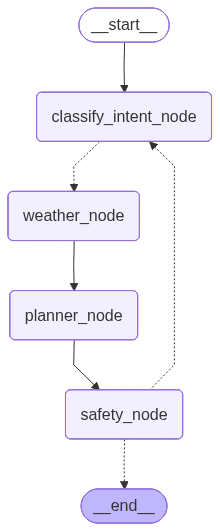

In [110]:
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [113]:
def noop_node(state):
    print("Reached placeholder node")
    return state

In [114]:

builder = StateGraph(TestOverallState)

builder.add_node("classify_intent_node", classify_intent_node)
builder.add_node("profiler_node", noop_node)
builder.add_node("weather_node", noop_node)
builder.add_node("planner_node", planner_node)
builder.add_node("route_node", noop_node)
builder.add_node("nutrition_node", noop_node)
builder.add_node("hydration_node", noop_node)
builder.add_node("safety_node", safety_node)

builder.add_edge(START, "profiler_node")
builder.add_edge("profiler_node", "classify_intent_node")
builder.add_conditional_edges(
    "classify_intent_node",
    route_from_intent,
    ["weather_node", "nutrition_node"],
)

# Both planner_node and nutrition_node eventually feed into safety_node
builder.add_edge("weather_node", "planner_node")
builder.add_edge("planner_node", "route_node")
builder.add_edge("route_node", "safety_node")
builder.add_edge("nutrition_node", "hydration_node")
builder.add_edge("hydration_node", "safety_node")

builder.add_conditional_edges(
    "safety_node",
    route_from_checker,
    ["classify_intent_node", END],
)
graph = builder.compile()


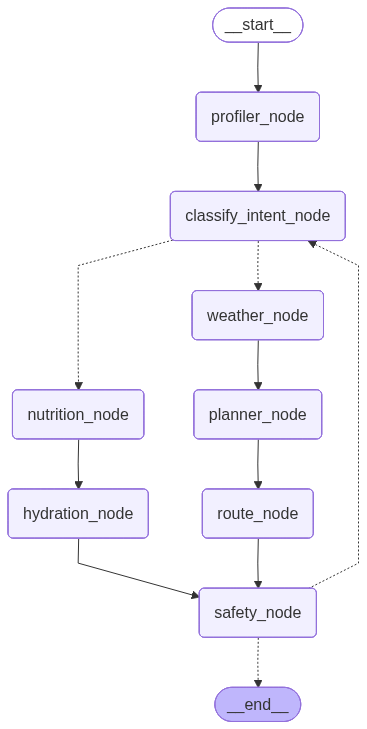

In [115]:
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))